## Cyclistic Bike Share Analysis

### Project Overview

This project analyzes bike-share trip data to identify usage patterns and compare member and casual riders.

### Project Objective
 - To study how casual riders and annual members use Cyclistic bikes differently.
 - To gain any other useful insights for designing new marketing strategies.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the dataset
df = pd.read_excel("2020_cyclists.xlsx")

## Data Overview

Let's start by examining the structure of our dataset.

In [3]:
#display first 3 rows of the dataset
df.head(3)

,ride_id,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_length,day of week,Hour,Route
0,EACB19130B0CDA4A,2020-01-21 20:06:00,2020-01-21 20:14:00,Western Ave & Leland Ave,Clark St & Leland Ave,member,0.005556,3,20,Western Ave & Leland Ave → Clark St & Leland Ave
1,8FED874C809DC021,2020-01-30 14:22:00,2020-01-30 14:26:00,Clark St & Montrose Ave,Southport Ave & Irving Park Rd,member,0.002778,5,14,Clark St & Montrose Ave → Southport Ave & Irvi...
2,789F3C21E472CA96,2020-01-09 19:29:00,2020-01-09 19:32:00,Broadway & Belmont Ave,Wilton Ave & Belmont Ave,member,0.002083,5,19,Broadway & Belmont Ave → Wilton Ave & Belmont Ave


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420496 entries, 0 to 420495
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype          
---  ------              --------------   -----          
 0   ride_id             420496 non-null  object         
 1   started_at          420496 non-null  datetime64[ns] 
 2   ended_at            420496 non-null  datetime64[ns] 
 3   start_station_name  420496 non-null  object         
 4   end_station_name    420496 non-null  object         
 5   member_casual       420496 non-null  object         
 6   ride_length         420496 non-null  timedelta64[ns]
 7   day of week         420496 non-null  int64          
 8   Hour                420496 non-null  int64          
 9   Route               420496 non-null  object         
dtypes: datetime64[ns](2), int64(2), object(5), timedelta64[ns](1)
memory usage: 32.1+ MB


### Initial observations
The dataset contains over 420,000 rows and 10 columns.

### Data Type conversion
The datatype of "ride_length" column has been float, which is supposed to be Timedelta, and the "ride_length" column is converted to timedelta datatype.

In [4]:
# #convert datatype to timedelta from float
df["ride_length"] = pd.to_timedelta(df["ride_length"], unit="D")

In [5]:
df["ride_length"].dtype

dtype('<m8[ns]')

### Checking the datatype quality for each column.
### Overview
Mixed data types in a single column can cause errors 
during computation, sorting, and exporting. This step identifies any columns 
that contain inconsistent data types.

### Explanation
### What it does
This code loops through every column in the DataFrame and checks whether 
all values share the same data type. If a column contains more than one 
data type, it prints the column name along with a breakdown of the types found.


In [13]:
for col in df.columns:
    types = df[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Column: {col}")
        print(types)

Column: ride_id
ride_id
<class 'str'>    420219
<class 'int'>       277
Name: count, dtype: int64


### Findings and reasoning for mix datatypes in ride_id column
There were mixed data types(string and integers) under ride_id column. However, there were mixed datatypes since the original file and I have no access to meta data or schema of the dataset, and the ride_id won't be primarily analyzed in this analysis and so, decided to leave them be.

## Data Cleaning
#### Step 1: Handle missing values for each column.

In [6]:
df.isnull().sum()

ride_id               0
started_at            0
ended_at              0
start_station_name    0
end_station_name      0
member_casual         0
ride_length           0
day of week           0
Hour                  0
Route                 0
dtype: int64

------------------------------------------------------------------------------------------
No missing values were found in the dataset.

### Step 2: Handle duplicates.
#### Checked if a row is the duplicate of a previous row.
There is no duplicated row in the dataset.

In [7]:
df[df.duplicated()]

,ride_id,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_length,day of week,Hour,Route


=================================================================================================================

#### Checking Data anomalies and outliers
#### First, ride_length column
Any rides having 0 ride_length will be considered anomalies and discarded. Rides with over 24 hours will be also considered outliers, but percentile and their occurances will be examined first.

In [7]:
# to check if there is any row where ride_length is lower than or equal to 0
df[df["ride_length"] <= pd.Timedelta(0)]

,ride_id,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_length,day of week,Hour,Route


In [14]:
# to check how many rows have ride_lenth over 1 day
long_rides = df[df["ride_length"] > pd.Timedelta(days=1)]

print(len(long_rides))
print(round(len(long_rides) / len(df) * 100, 3))

0
0.0


In [15]:
df["ride_length"].quantile([0.99, 0.995, 0.999]).round("s")

0.990   0 days 01:23:00
0.995   0 days 02:02:00
0.999   0 days 08:37:30
Name: ride_length, dtype: timedelta64[ns]

--------------------------------------------------------------------------------------------------------------------

#### Excluding outliers from analysis
The 99th percentile ride duration was 1 hour 26 minutes and the 99.9th percentile was 17 hours 17 minutes. Rides exceeding 24 hours represented only 290 observations (0.073% of the dataset) and were treated as outliers and excluded from subsequent analysis.

In [10]:
# to delete or exclude any rows where ride_length is over 1 day or 24 hours
df = df[df["ride_length"] <= pd.Timedelta(days=1)]

### Resetting index after deleting outlier rows

In [11]:
df = df.reset_index(drop=True)

## Insights and findings
### 1.[member vs casual riders distribution]
#### Objective: Understand the propotion of rides taken by members and casual riders.

### Why This Matters
Knowing which customer segment generates most rides helps the company decide whether to focus on:
- Membership acquisition campaigns
- Casual rider promotions
- Customer retention strategies


In [14]:
ride_counts = df["member_casual"].value_counts()
print(ride_counts)

member_casual
member    375930
casual     44566
Name: count, dtype: int64


In [16]:
df["member_casual"].value_counts(normalize=True).mul(100).round(2)

member_casual
member    89.4
casual    10.6
Name: proportion, dtype: float64

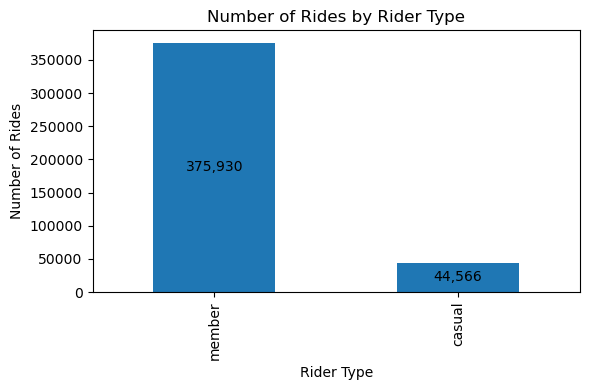

In [32]:
total_rides = df["member_casual"].value_counts()

ax = total_rides.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Rides by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Number of Rides")
# add label
for container in ax.containers:
    ax.bar_label(
        container, label_type="center", fmt='{:,.0f}')
plt.tight_layout()
plt.show()

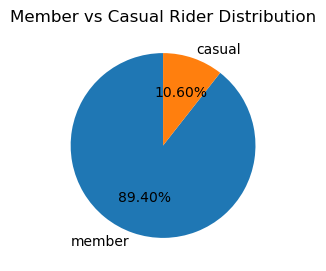

In [34]:
# ride_counts need to be defined first, it is a variable
plt.figure(figsize=(3,3))

plt.pie(
    ride_counts,
    labels=ride_counts.index,
    autopct="%1.2f%%",
    startangle = 90
)

plt.title("Member vs Casual Rider Distribution")
plt.show()


### Insights [member vs casual rider distribution]
- Members account for almost 90% of all rides.
- Casual riders account for around 10% of all rides.
- The majority of ride demand comes from members, indicating strong recurring usage.

#### Marketing Recommendations
- Casual riders  ride less often but take their time, going on longer scenic trips. Likely to be tourists or leisure riders exploring the city. Highlight fun/leisure routes and offer membership discounts during peak casual-rider seasons to convert them to members.
- Meanwhile focus on retaining members because they generate most ride activity.

-----------------------------------------------------

## 2.[member vs casual rider distribution by hour]
#### Objective: To understand the usage pattern and behaviour of each rider segment.
#### Why it matter:
By knowing peak hours for each rider segment, we can determine whether they use the bikes for leisure or daily commute. We can also know when to raise and reduce bike availability. Lastly, from this insight, we can schedule for maintenance during off-peak hours.

In [44]:
pd.crosstab(df["Hour"], df["member_casual"], margins=True)

member_casual,casual,member,All
Hour,,,
0,308,1403,1711
1,223,830,1053
2,135,514,649
3,100,374,474
4,55,1027,1082
5,135,5145,5280
6,332,14771,15103
7,722,31502,32224
8,1174,41200,42374


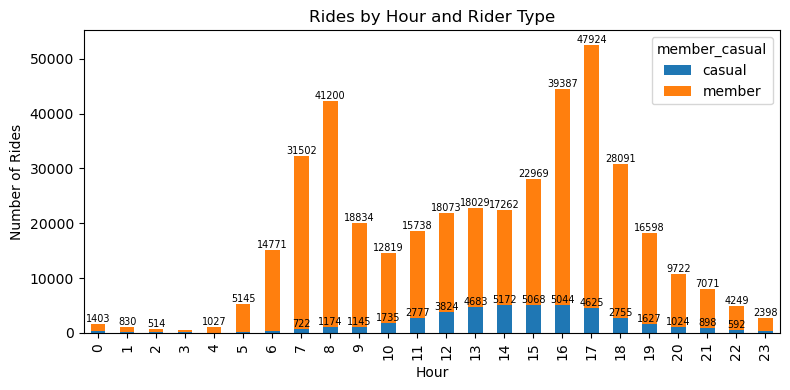

In [36]:
hour_member = pd.crosstab(
    df["Hour"],
    df["member_casual"]
)

ax = hour_member.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

plt.title("Rides by Hour and Rider Type")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")

# Add data labels
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=7,
                labels = [int(v) if v > 500 else " " for v in container.datavalues])

plt.tight_layout()
plt.show()

### Insights: [member vs casual rider distribution by hour]
Peak hours for member riders are between 7 to 9 in the morning, and 3 to 6 in the evening. This suggests that most of members are from the workforce who use bikes to commute to their works daily. Casual riders use bikes mostly between 12pm and 6pm. This time period would be best if any marketing campaign targeted at casual riders are to be launced. Between midnight 12am and 3 am, the off-peak hours are best for performing maintenance service.

------------------------------------------------------------------------------------

## 3.[member vs casual riders in days of week]
In this analysis for day of week, index start from 1=Sunday.

In [59]:
df[df["member_casual"] == "member"] \
    .groupby("day of week")["member_casual"] \
    .value_counts().sort_values(ascending=False)
# members usually use bikes during weekdays and weekends have lowest rides for members.

day of week  member_casual
3            member           69304
4            member           63596
2            member           61558
5            member           60820
6            member           55126
1            member           35659
7            member           29867
Name: count, dtype: int64

In [56]:
# Convert days of week into dasy in categorical
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["day_name"] = pd.Categorical(
    df["started_at"].dt.day_name(),
    categories=days_order,
    ordered=True
)

[<BarContainer object of 7 artists>]


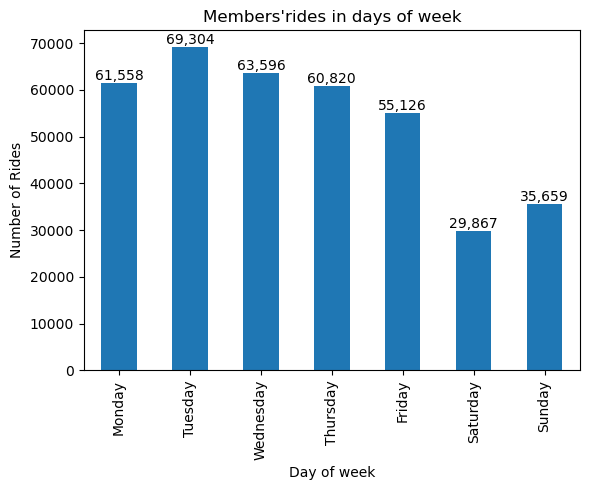

In [58]:
day_week = df[df["member_casual"] == "member"] \
    .groupby("day_name", observed=False)["member_casual"] \
    .count()

ax = day_week.plot(
    kind = "bar",
    figsize = (6,5)
)

plt.title("Members'rides in days of week")
plt.xlabel("Day of week")
plt.ylabel("Number of Rides")

print(ax.containers)
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fmt= '{:,.0f}')
plt.tight_layout()
plt.show()

In [17]:
df[df["member_casual"] == "casual"] \
    .groupby("day of week")["member_casual"]\
    .value_counts().sort_values(ascending=False)

day of week  member_casual
1            casual           14782
7            casual            7437
4            casual            5186
6            casual            4626
3            casual            4592
5            casual            4211
2            casual            3732
Name: count, dtype: int64

### Insights: [member vs casual riders in days of week]
The analysis reveals a clear difference in riding behavior between member and casual users. Members demonstrate higher ride volumes during weekdays, suggesting that the service is commonly used for daily commuting. In contrast, casual riders are more active on weekends, indicating a greater tendency toward leisure, recreational or non-work-related trips.

------------------------------------------------------------------------

### 4.[Average ride length by member vs casual riders]

In [21]:
df.groupby("member_casual")["ride_length"].mean().round("s")

member_casual
casual   0 days 00:39:55
member   0 days 00:11:34
Name: ride_length, dtype: timedelta64[ns]

### 5.[Average ride length by day of week]

In [39]:
df.groupby("day of week")["ride_length"].mean().round('s').sort_values(ascending=False)
#weedend has average longer rides

day of week
1   0 days 00:22:07
7   0 days 00:17:47
4   0 days 00:13:45
6   0 days 00:13:20
3   0 days 00:12:52
5   0 days 00:12:51
2   0 days 00:12:34
Name: ride_length, dtype: timedelta64[ns]

### Insights:
These further insights prove that members are likely to use the bike for daily commutes-short, predictable trips to work or school in the weekdays. Meahwhile, casual riders are more likely to be tourists or leisure riders who use bikes to explore the city or go on longer scenic trips.
 - Members ride more often but for shorter trips.
 - Casual riders ride less often but take their time.

--------------------------------------------------------------------------------------

### 6.[Top 10 most used routes]
#### Why it matter:
 Earlier findings suggest that members mainly use the bike-sharing service for routine commuting activities. However, these findings alone do not distinguish whether the majority of member trips are associated with educational institutions or workplaces. Analyzing the most frequently traveled routes can provide valuable context and help estimate whether students or working professionals represent the larger share of the membership base.

In [44]:
df["Route"].value_counts().head(10)

Route
Ellis Ave & 60th St → University Ave & 57th St                 478
Lake Shore Dr & Monroe St → Lake Shore Dr & Monroe St          456
Canal St & Adams St → Michigan Ave & Washington St             455
Michigan Ave & Washington St → Clinton St & Washington Blvd    453
University Ave & 57th St → Ellis Ave & 60th St                 421
Canal St & Madison St → Michigan Ave & Washington St           406
Ellis Ave & 60th St → Ellis Ave & 55th St                      364
Columbus Dr & Randolph St → Clinton St & Washington Blvd       356
Lake Shore Dr & Monroe St → Streeter Dr & Grand Ave            333
Clinton St & Washington Blvd → Michigan Ave & Washington St    330
Name: count, dtype: int64

--------------------------------------------------

### 7.[Top 5 most used start stations and end stations]
#### Objective:
To assist in estimating whether students or working professionals represent the larger share of the membership base.

In [64]:
df["start_station_name"].value_counts().head(5)

start_station_name
Canal St & Adams St             7781
Clinton St & Madison St         6755
Clinton St & Washington Blvd    5911
Kingsbury St & Kinzie St        4600
Columbus Dr & Randolph St       4390
Name: count, dtype: int64

In [65]:
df["end_station_name"].value_counts().head(5)

end_station_name
Canal St & Adams St             8290
Clinton St & Washington Blvd    7137
Clinton St & Madison St         6798
Kingsbury St & Kinzie St        4592
Michigan Ave & Washington St    4215
Name: count, dtype: int64